# Example of likelihood calcularion for the spectroscopic observables

__Warning__: to run this part of the notebook it is necessary to first install the comet package. To do so, just get the last version (2.0.5) of the code from PyPI with `pip install comet-emu`

__Please note__: in case you already have a previous installation of comet (1.x) in your system (or environment), the installation of this specific version could create some incompatibility issues. Therefore, we recommend to create a fresh new environment and installing this version from scratch. Alternatively, you can uninstall your current version of comet with `pip uninstall comet-emu`, explicitly removing the comet folder from your installation path, and finally installing the new PyPI version.

In this part we make use of the EFT model

In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# cloelib imports
from cloelib.cosmology.camb_cosmology import CAMBBackground
from cloelib.observables.CometEFT_spectro import CometEFT_SpectroPower

# cloelike imports
from cloelike.EuclidLikelihood_GCSpectro_Pks import EuclidLikelihoodGCspectroPks

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

Warning! "libgrid.so" not found, bispectrum binning options will not be available.


### Define redshifts and read data and fiducial cosmology

Soon, the reading of the input data will happen via Euclidlib

In [2]:
# Redshifts of the samples (we transform them to strings to have identifiers of the bins)
redshifts = [1.0, 1.2, 1.4, 1.65]
labels = [str(z).strip('0') for z in redshifts]

data = {
    # Data (we fill this part below)
    'GCspectro': {},
    # Fiducial cosmology (required for geometrical (AP) distortions)
    'fiducial_cosmology': {
        'H0': 67.0,
        'Omega_cdm0': 0.27, 'Omega_b0': 0.049, 'Omega_k0': 0.0, 'mnu': 0.0,
        'w0': -1.0, 'wa': 0.0,
        'ns': 0.96, 'As': 2.1e-9,
        'gamma_MG': 0.545       
    }
}

# Rescaling of the units (as, at the moment, cloelib works in Mpc units, while the data vectors are stored in Mpc/h units)
fid_h = data['fiducial_cosmology']['H0'] / 100.0
k_fac = fid_h
pk_fac = 1.0 / fid_h**3
cov_fac = 1.0 / fid_h**6

# Number densities
nbar = np.array([2.042611E-03, 1.02876011E-03, 0.58531983E-03, 0.313402E-03]) * fid_h**3

# Here we read the data vectors and covariance matrices and store them into the data dictionary
def get_index(multipole, scale, scale_dict):
    offset = sum(len(scale_dict[ell]) for ell in multipoles if ell < multipole)
    return offset + np.where(scale_dict[multipole] == scale)[0][0]

for ii,z in enumerate(labels):
    # Looping over the identifiers (redshifts)
    data['GCspectro'][z] = {}

    # Storing data vectors
    filename = f'/Users/pezzotta/work/cloe/data/cov_EFT_z{z}.fits'
    hdul = fits.open(filename)
    average = hdul['AVERAGE'].data
    data['GCspectro'][z]['k'] = average['SCALE_1DIM'] * k_fac
    data['GCspectro'][z]['pk0'] = average['AVERAGE0'] * pk_fac
    data['GCspectro'][z]['pk2'] = average['AVERAGE2'] * pk_fac
    data['GCspectro'][z]['pk4'] = average['AVERAGE4'] * pk_fac

    # Storing covariance matrices
    covariance = hdul['COVARIANCE'].data
    scale_i = covariance["SCALE_1DIM-I"]
    multipole_i = covariance["MULTIPOLE-I"]
    scale_j = covariance["SCALE_1DIM-J"]
    multipole_j = covariance["MULTIPOLE-J"]
    covariance = covariance["COVARIANCE"]

    multipoles = np.array([0, 2, 4])
    scale_dict = {ell: np.unique(scale_i[multipole_i == ell]) for ell in multipoles}
    matrix_size = sum(len(scale_dict[ell]) for ell in multipoles)
    cov_matrix = np.zeros((matrix_size, matrix_size))
    for s_i, m_i, s_j, m_j, cov in zip(scale_i, multipole_i, scale_j, multipole_j, covariance):
        i = get_index(m_i, s_i, scale_dict)
        j = get_index(m_j, s_j, scale_dict)
        cov_matrix[i, j] = cov
    data['GCspectro'][z]['cov'] = cov_matrix * cov_fac

    # Storing number densities
    data['GCspectro'][z]['nbar'] = nbar[ii]    

### Define scale cuts

In [3]:
settings = {
    'scale_cuts': {
        'GCspectro': {
            'bin1': {'ell0': [0.0, 0.20], 'ell2': [0.0, 0.15], 'ell4': [0.0, 0.15]},
            'bin2': {'ell0': [0.0, 0.25], 'ell2': [0.0, 0.20], 'ell4': [0.0, 0.20]},
            'bin3': {'ell0': [0.0, 0.25], 'ell2': [0.0, 0.20], 'ell4': [0.0, 0.20]},
            'bin4': {'ell0': [0.0, 0.30], 'ell2': [0.0, 0.25], 'ell4': [0.0, 0.25]}
        }
    }
}

# Also in this case we have passed the scale cuts in Mpc/h units, so we need to transform them into Mpc
settings = {
    'scale_cuts': {
        'GCspectro': {
            bin_key: {ell_key: [v * fid_h for v in values] for ell_key, values in bin_values.items()}
            for bin_key, bin_values in settings['scale_cuts']['GCspectro'].items()
        }
    }
}

### Create instance of GCspectro likelihood

This requires specifying the data and settings dictionaries, plus a type of Background and SpectroPower objects

In [4]:
like = EuclidLikelihoodGCspectroPks(data=data, settings=settings, Background=CAMBBackground, SpectroPower=CometEFT_SpectroPower)

Now, we can create a dicitonary containing the ensemble set of cosmological and nuisance parameters, and evaluate the likelihood

In [5]:
parameters = {
    'H0': 67.0,
    'Omega_cdm0': 0.27, 'Omega_b0': 0.049, 'Omega_k0': 0.0, 'mnu': 0.0,
    'w0': -1.0, 'wa': 0.0,
    'ns': 0.96, 'As': 2.1e-9,
    'gamma_MG': 0.545,
    'b1': np.array([1.412, 1.769, 2.039, 2.496]),
    'b2': np.array([0.695, 0.870, 1.162, 2.010]),
    'bG2': np.array([-0.156, -0.299, -0.400, -0.555]),
    'bGam3': np.array([0.323, 0.621, 0.827, 1.137]),
    'c0': np.array([30.948, 37.116, 36.738, 53.627]),
    'c2': np.array([46.233, 53.071, 48.626, 60.962]),
    'c4': np.array([10.057, 10.385, 8.643, 8.711]),
    'cnlo': np.array([0.0, 0.0, 0.0, 0.0]),
    'NP0': np.array([1.056, 1.152, 1.144, 1.309]),
    'NP20': np.array([0.0, 0.0, 0.0, 0.0]),
    'NP22': np.array([0.0, 0.0, 0.0, 0.0]),
    'fout': np.array([0.0, 0.0, 0.0, 0.0]),
    'sigmaz': np.array([0.0, 0.0, 0.0, 0.0])
}

print (-2*like.loglike(parameters))

5.891766452608903e-09


We can easily reevaluate the $\chi^2$ changing the parameters

In [6]:
parameters['H0'] = 70.0
print (-2*like.loglike(parameters))

parameters['H0'] = 67.0
parameters['b1'] = np.repeat(2.0, 4)
print (-2*like.loglike(parameters))

parameters['w0'] = -1.2
print (-2*like.loglike(parameters))

parameters['Omega_k0'] = 0.2
print (-2*like.loglike(parameters))

parameters['bGam3'] = np.repeat(0.5, 4)
print (-2*like.loglike(parameters))

54986.321757500504
391101.88771686115
405431.3141845336
187800.89611420708
164451.1893343323


Let's check them against the built-in Comet $\chi^2$ method

In [7]:
from comet import comet

emu = comet('EFT', use_Mpc=True, bias_basis='AssBauGre')

nbar = np.array([2.042611E-03, 1.02876011E-03, 0.58531983E-03, 0.313402E-03]) * 0.67**3
emu.define_nbar(nbar=nbar)

params_fid = {
    'h': np.repeat(0.67, 4),
    'wc': np.repeat(0.27 * 0.67**2, 4),
    'wb': np.repeat(0.049 * 0.67**2, 4),
    'ns': np.repeat(0.96, 4),
    'w0': np.repeat(-1.0, 4),
    'wa': np.repeat(0.0, 4),
    'As': np.repeat(2.1, 4),
    'Mnu': np.repeat(0.0, 4),
    'z': np.array([1.0, 1.2, 1.4, 1.65])
}

for i,z in enumerate(['1.', '1.2', '1.4', '1.65']):
    params_fid_z = {key:params_fid[key][i] for key in params_fid}
    emu.define_data_set(obs_id = f'z{i+1}',
                        bins = data['GCspectro'][z]['k'],
                        signal = np.array([data['GCspectro'][z]['pk0'], data['GCspectro'][z]['pk2'], data['GCspectro'][z]['pk4']]).T,
                        cov = data['GCspectro'][z]['cov'], theory_cov = True, zeff = float(z), fiducial_cosmology = params_fid_z, nbar=nbar[i])
    
params = {'h': np.repeat(0.67, 4),
          'wc': np.repeat(0.27*0.67**2, 4),
          'wb': np.repeat(0.049*0.67**2, 4),
          'w0': np.repeat(-1.0, 4),
          'wa': np.repeat(0.0, 4),
          'ns': np.repeat(0.96, 4),
          'As': np.repeat(2.1, 4),
          'Mnu': np.repeat(0.0, 4),
          'z': np.array([1.0, 1.2, 1.4, 1.65]),
          'b1': np.array([1.412, 1.769, 2.039, 2.496]),
          'b2': np.array([0.695, 0.870, 1.162, 2.010]),
          'bG2': np.array([-0.156, -0.299, -0.400, -0.555]),
          'bGam3': np.array([0.323, 0.621, 0.827, 1.137]),
          'c0': np.array([30.948, 37.116, 36.738, 53.627]),
          'c2': np.array([46.233, 53.071, 48.626, 60.962]),
          'c4': np.array([10.057, 10.385, 8.643, 8.711]),
          'cnlo': np.array([0.0, 0.0, 0.0, 0.0]),
          'NP0': np.array([1.056, 1.152, 1.144, 1.309]),
          'NP20': np.array([0.0, 0.0, 0.0, 0.0]),
          'NP22': np.array([0.0, 0.0, 0.0, 0.0]),
          'f_out': np.array([0.0, 0.0, 0.0, 0.0]),
          'sigma_z': np.array([0.0, 0.0, 0.0, 0.0])
}

scale_cuts = {
    'z1': [0.2 * 0.67, 0.15 * 0.67, 0.15 * 0.67],
    'z2': [0.25 * 0.67, 0.2 * 0.67, 0.2 * 0.67],
    'z3': [0.25 * 0.67, 0.2 * 0.67, 0.2 * 0.67],
    'z4': [0.3 * 0.67, 0.25 * 0.67, 0.25 * 0.67]
}

print (emu.chi2(['z1','z2','z3','z4'], params, scale_cuts, de_model='w0wa'))

params['h'] = np.repeat(0.7, 4)
params['wc'] = np.repeat(0.27 * 0.7**2, 4)
params['wb'] = np.repeat(0.049 * 0.7**2, 4)

print (emu.chi2(['z1','z2','z3','z4'], params, scale_cuts, de_model='w0wa'))

params['h'] = np.repeat(0.67, 4)
params['wc'] = np.repeat(0.27 * 0.67**2, 4)
params['wb'] = np.repeat(0.049 * 0.67**2, 4)
params['b1'] = np.repeat(2.0, 4)

print (emu.chi2(['z1','z2','z3','z4'], params, scale_cuts, de_model='w0wa'))

params['w0'] = np.repeat(-1.2, 4)

print (emu.chi2(['z1','z2','z3','z4'], params, scale_cuts, de_model='w0wa'))

params['Ok'] = np.repeat(0.2, 4)

print (emu.chi2(['z1','z2','z3','z4'], params, scale_cuts, de_model='w0wa'))

params['bGam3'] = np.repeat(0.5, 4)

print (emu.chi2(['z1','z2','z3','z4'], params, scale_cuts, de_model='w0wa'))

[3.57036664e-07]
[55022.64144638]
[391101.65968905]
[405410.42814073]
[187781.50399773]
[164433.51638758]


Let's go back to the original parameters

In [8]:
parameters = {
    'H0': 67.0,
    'Omega_cdm0': 0.27, 'Omega_b0': 0.049, 'Omega_k0': 0.0, 'mnu': 0.0,
    'w0': -1.0, 'wa': 0.0,
    'ns': 0.96, 'As': 2.1e-9,
    'gamma_MG': 0.545,
    'b1': np.array([1.412, 1.769, 2.039, 2.496]),
    'b2': np.array([0.695, 0.870, 1.162, 2.010]),
    'bG2': np.array([-0.156, -0.299, -0.400, -0.555]),
    'bGam3': np.array([0.323, 0.621, 0.827, 1.137]),
    'c0': np.array([30.948, 37.116, 36.738, 53.627]),
    'c2': np.array([46.233, 53.071, 48.626, 60.962]),
    'c4': np.array([10.057, 10.385, 8.643, 8.711]),
    'cnlo': np.array([0.0, 0.0, 0.0, 0.0]),
    'NP0': np.array([1.056, 1.152, 1.144, 1.309]),
    'NP20': np.array([0.0, 0.0, 0.0, 0.0]),
    'NP22': np.array([0.0, 0.0, 0.0, 0.0]),
    'fout': np.array([0.0, 0.0, 0.0, 0.0]),
    'sigmaz': np.array([0.0, 0.0, 0.0, 0.0])
}

print (-2*like.loglike(parameters))

5.891766452608903e-09


In [9]:
params = {'h': np.repeat(0.67, 4),
          'wc': np.repeat(0.27*0.67**2, 4),
          'wb': np.repeat(0.049*0.67**2, 4),
          'w0': np.repeat(-1.0, 4),
          'wa': np.repeat(0.0, 4),
          'ns': np.repeat(0.96, 4),
          'As': np.repeat(2.1, 4),
          'Mnu': np.repeat(0.0, 4),
          'Ok': np.repeat(0.0, 4),
          'z': np.array([1.0, 1.2, 1.4, 1.65]),
          'b1': np.array([1.412, 1.769, 2.039, 2.496]),
          'b2': np.array([0.695, 0.870, 1.162, 2.010]),
          'bG2': np.array([-0.156, -0.299, -0.400, -0.555]),
          'bGam3': np.array([0.323, 0.621, 0.827, 1.137]),
          'c0': np.array([30.948, 37.116, 36.738, 53.627]),
          'c2': np.array([46.233, 53.071, 48.626, 60.962]),
          'c4': np.array([10.057, 10.385, 8.643, 8.711]),
          'cnlo': np.array([0.0, 0.0, 0.0, 0.0]),
          'NP0': np.array([1.056, 1.152, 1.144, 1.309]),
          'NP20': np.array([0.0, 0.0, 0.0, 0.0]),
          'NP22': np.array([0.0, 0.0, 0.0, 0.0]),
          'f_out': np.array([0.0, 0.0, 0.0, 0.0]),
          'sigma_z': np.array([0.0, 0.0, 0.0, 0.0])
}

print (emu.chi2(['z1','z2','z3','z4'], params, scale_cuts, de_model='w0wa'))

[3.57036664e-07]


### Analytical marginalization of linear parameters

To switch on analytical marginalization of linear parameters $(b_{\Gamma_3},\,c_0,\,c_2,\,c_4,\,c_{\rm nlo},\,N_{P,0},\,N_{P,20},\,N_{P,22})$, we need to define a new dictionary containing means and standard deviations assumed for the gaussian prior of the marginalization and pass it to the constructor of the likelihood class

In [10]:
AM_priors = {
    '1.': {'bGam3': [0.0, 5.0], 'c0': [0.0, 200.0]},
    '1.2': {'bGam3': [0.0, 5.0], 'c0': [0.0, 200.0]},
    '1.4': {'bGam3': [0.0, 5.0], 'c0': [0.0, 200.0]},
    '1.65': {'bGam3': [0.0, 5.0], 'c0': [0.0, 200.0]},
}
like = EuclidLikelihoodGCspectroPks(data=data, settings=settings, Background=CAMBBackground, SpectroPower=CometEFT_SpectroPower, AM_priors=AM_priors)

print (-2*like.loglike_AM(parameters))

31.573346437769942


We can explore different marginalizations:

In [11]:
AM_priors = {
    '1.': {'NP0': [1.0, 2.0]},
    '1.2': {'c0': [0.0, 200.0], 'c2': [0.0, 200.0], 'c4': [0.0, 200.0]},
    '1.4': {'bGam3': [0.0, 5.0], 'cnlo': [0.0, 200.0]},
    '1.65': {'bGam3': [0.0, 5.0], 'c0': [0.0, 200.0]},
}
like = EuclidLikelihoodGCspectroPks(data=data, settings=settings, Background=CAMBBackground, SpectroPower=CometEFT_SpectroPower, AM_priors=AM_priors)

print (-2*like.loglike_AM(parameters))

19.931512850162107


In [12]:
AM_priors = {
    '1.': {'NP0': [1.0, 2.0]},
    '1.2': {'c0': [0.0, 200.0], 'c2': [0.0, 200.0], 'c4': [0.0, 200.0]},
    '1.4': {'bGam3': [0.0, 5.0], 'cnlo': [0.0, 200.0], 'NP22': [0.0, 30.0]},
    '1.65': {'bGam3': [0.0, 5.0], 'c0': [0.0, 200.0], 'NP20': [0.0, 30.0], 'NP22': [0.0, 30.0]},
}
like = EuclidLikelihoodGCspectroPks(data=data, settings=settings, Background=CAMBBackground, SpectroPower=CometEFT_SpectroPower, AM_priors=AM_priors)

print (-2*like.loglike_AM(parameters))

22.808602989112842


Let's check again against Comet

In [13]:
AM_priors_comet = {'z1': {'bGam3': [0.0, 5.0], 'c0': [0.0, 200.0]},
                   'z2': {'bGam3': [0.0, 5.0], 'c0': [0.0, 200.0]},
                   'z3': {'bGam3': [0.0, 5.0], 'c0': [0.0, 200.0]},
                   'z4': {'bGam3': [0.0, 5.0], 'c0': [0.0, 200.0]}}

print (emu.chi2(['z1','z2','z3','z4'], params, scale_cuts, de_model='w0wa', AM_priors=AM_priors_comet))

[31.57333448]


In [14]:
AM_priors_comet = {'z1': {'NP0': [1.0, 2.0]},
                   'z2': {'c0': [0.0, 200.0], 'c2': [0.0, 200.0], 'c4': [0.0, 200.0]},
                   'z3': {'bGam3': [0.0, 5.0], 'cnlo': [0.0, 200.0]},
                   'z4': {'bGam3': [0.0, 5.0], 'c0': [0.0, 200.0]}
                  }

print (emu.chi2(['z1','z2','z3','z4'], params, scale_cuts, de_model='w0wa', AM_priors=AM_priors_comet))

[19.93151802]


In [15]:
AM_priors_comet = {'z1': {'NP0': [1.0, 2.0]},
                   'z2': {'c0': [0.0, 200.0], 'c2': [0.0, 200.0], 'c4': [0.0, 200.0]},
                   'z3': {'bGam3': [0.0, 5.0], 'cnlo': [0.0, 200.0], 'NP22': [0.0, 30.0]},
                   'z4': {'bGam3': [0.0, 5.0], 'c0': [0.0, 200.0], 'NP20': [0.0, 30.0], 'NP22': [0.0, 30.0]}
                  }

print (emu.chi2(['z1','z2','z3','z4'], params, scale_cuts, de_model='w0wa', AM_priors=AM_priors_comet))

[22.80860752]


### Likelihood

In [16]:
like = EuclidLikelihoodGCspectroPks(data=data, settings=settings, Background=CAMBBackground, SpectroPower=CometEFT_SpectroPower)

omch2 = np.linspace(0.12, 0.1220, 200)
likelihood = []

for val in omch2:
    parameters['Omega_cdm0'] = val / (parameters['H0'] / 100.0)**2
    likelihood.append(like.loglike(parameters))

(0.1209, 0.1215)

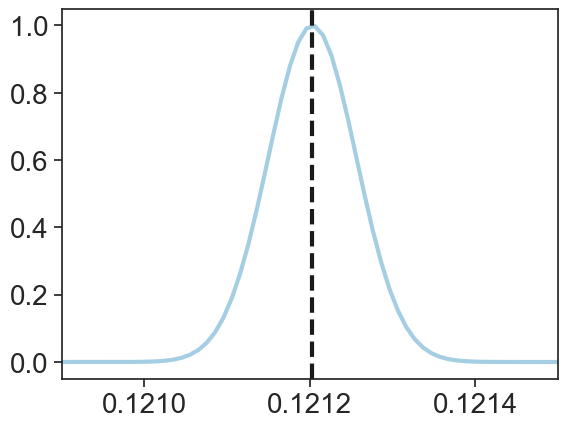

In [17]:
plt.plot(omch2, np.array(np.exp(likelihood)))
plt.axvline(0.27*0.67**2, color='k', ls='--')
plt.xlim([0.1209, 0.1215])